# Hypothesis testing

Bootstrap Mean: 0.0658541865318489, Bootstrap Std Dev: 0.12623333403967435


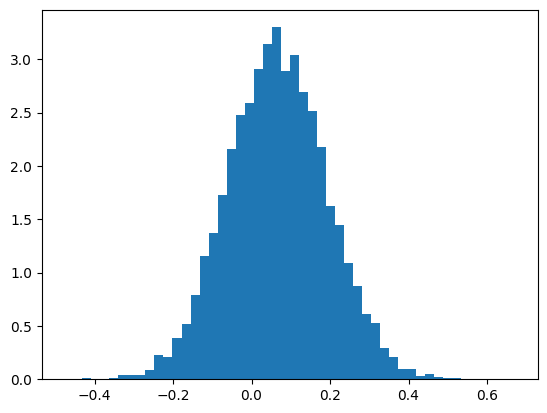

In [4]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt

x1_mean = 0
x1_stddev = 1
x1 = np.random.normal(loc=x1_mean, scale=x1_stddev, size=50)
n_samples = 50
means = []
n_boot = 10000
for i in range(1, n_boot):
    boot = sklearn.utils.resample(x1, replace=True, n_samples=n_samples)
    means.append(np.mean(boot))

plt.hist(means, bins=50, density=True)

mn_boot = np.mean(means)
std_boot = np.std(means)
print(f"Bootstrap Mean: {mn_boot}, Bootstrap Std Dev: {std_boot}")

## Significance level

In [10]:
np.sort(means)
num = int(len(means) * 0.025)
means = means[num:-num]
first = means[0]
last = means[-1]
print(f"95% Confidence Interval: [{first}, {last}]")

95% Confidence Interval: [-0.21294145673165532, -0.39066413727795046]


Zakładając, że rozkład jest normalny zastosuj rozkład t-Studenta i funkcję t.interval

In [13]:
from scipy import stats

alpha = 0.05
SE = np.std(x1) / np.sqrt(len(x1)) #błąd standardowy dla rozkładu normlanego
print(f"Standard Error: {SE}")
t_student_interval = stats.t.interval(1 - alpha, df=n_samples - 1, loc=np.mean(x1), scale=SE)  # uwaga! pierwszy parametr oznacza poziom ufności
print(f"T-Student 95% Confidence Interval: {t_student_interval}")

Standard Error: 0.11157741484495533
T-Student 95% Confidence Interval: (np.float64(-0.5803054665485082), np.float64(-0.13185904675787088))


Stosując bs.bootstrap określ jaki jest przedział ufności dla wartości średniej i odchylenia standardowego

In [14]:
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats


bs_mean_interval = bs.bootstrap(x1, stat_func=bs_stats.mean)
bs_std_interval = bs.bootstrap(x1, stat_func=bs_stats.std)
print(f"Bootstrapped Mean 95% Confidence Interval: {bs_mean_interval}")
print(f"Bootstrapped Std Dev 95% Confidence Interval: {bs_std_interval}")

Bootstrapped Mean 95% Confidence Interval: -0.35608225665318954    (-0.5720012599233397, -0.13376667823417698)
Bootstrapped Std Dev 95% Confidence Interval: 0.7889714666413247    (0.6778427424777229, 0.9244578827635272)


Wygeneruj i wyświetl histogram dla rozkładu skośnego

(array([0.41935833, 0.41935833, 0.        , 0.41935833, 0.83871665,
        0.41935833, 0.83871665, 1.25807498, 0.        , 1.67743331,
        0.41935833, 0.41935833, 0.83871665, 0.41935833, 0.        ,
        0.41935833, 0.        , 0.        , 0.        , 0.41935833,
        0.41935833, 0.        , 0.83871665, 0.83871665, 0.        ,
        0.41935833, 0.        , 0.41935833, 1.67743331, 0.        ,
        0.41935833, 1.25807498, 0.41935833, 0.        , 0.83871665,
        0.        , 0.41935833, 0.41935833, 0.41935833, 0.83871665,
        0.        , 0.        , 0.83871665, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.41935833, 0.83871665]),
 array([-0.12669742, -0.07900551, -0.0313136 ,  0.01637832,  0.06407023,
         0.11176214,  0.15945405,  0.20714596,  0.25483787,  0.30252978,
         0.35022169,  0.3979136 ,  0.44560551,  0.49329742,  0.54098934,
         0.58868125,  0.63637316,  0.68406507,  0.73175698,  0.77944889,
         0.8271408 ,  0.87

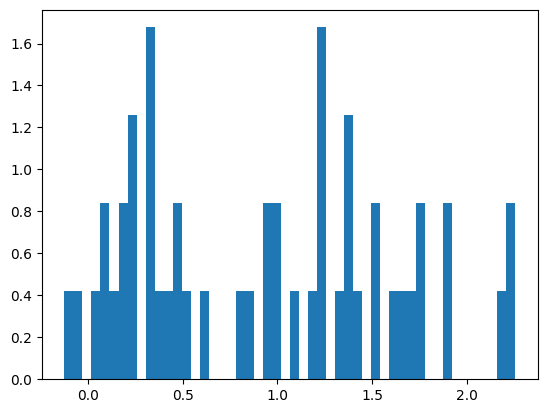

In [16]:
x2 = stats.skewnorm.rvs(a=5, size=50)
plt.hist(x2, bins=50, density=True)

Zastosuj metodę 1 lub 3 oraz metodę 2

In [18]:
# Oblicz wartość średnią i odchylenie standardowe oraz przedziały ufności dla x2
bs_mean_interval = bs.bootstrap(x2, stat_func=bs_stats.mean)
bs_std_interval = bs.bootstrap(x2, stat_func=bs_stats.std)
print(f"Bootstrapped Mean 95% Confidence Interval: {bs_mean_interval}")
print(f"Bootstrapped Std Dev 95% Confidence Interval: {bs_std_interval}")
# Zastosuj również metodę przedziału t-Studenta
SE = np.std(x2) / np.sqrt(len(x2)) #błąd standardowy dla rozkładu normlanego
print(f"Standard Error: {SE}")
t_student_interval = stats.t.interval(1 - alpha, df=n_samples - 1, loc=np.mean(x2), scale=SE)  # uwaga! pierwszy parametr oznacza poziom ufności
print(f"T-Student 95% Confidence Interval: {t_student_interval}")

Bootstrapped Mean 95% Confidence Interval: 0.939393969728376    (0.7542657338031169, 1.1217616979633391)
Bootstrapped Std Dev 95% Confidence Interval: 0.6674438915036096    (0.5880051612117215, 0.7647380136161902)
Standard Error: 0.09439082034874813
T-Student 95% Confidence Interval: (np.float64(0.749708514543217), np.float64(1.129079424913535))


Z samych wyników nie widać, która metoda radzi sobie lepiej. Rozkład T-Studenta zakłada normalność danych, a więc bootstrap powinien lepiej radzić sobie z asymetrią.

## Testowanie hipotez

### 1. T- test- dla zmiennych o rozkładzie zbliżonym do normalnego

In [8]:
from scipy import stats


n_samples = 50
rvs1 = stats.norm.rvs(loc=0, scale=1, size=n_samples)
rvs2 = stats.norm.rvs(loc=0.2, scale=0.5, size=n_samples)
(stats, p_value) = stats.ttest_ind(rvs1, rvs2, equal_var = False)
print(f"T-test statistics: {stats}, p-value: {p_value}")

T-test statistics: 0.5174551773915695, p-value: 0.6064122121441473


### 2. Test permutacyjny- dla zmiennych o dowolnym rozkładzie

In [6]:
# from mlxtend.evaluate import permutation_test
from scipy.stats import permutation_test
def statistic(x, y, axis=0):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

p_value = permutation_test((rvs1, rvs2), statistic,
                           n_resamples=np.inf, alternative='two-sided')
print(f"Permutation test p-value: {p_value}")

KeyboardInterrupt: 

## Moc testu

In [12]:
from statsmodels.stats.power import TTestIndPower

alpha = 0.05
mean1 = np.mean(rvs1)
mean2 = np.mean(rvs2)
std1 = np.std(rvs1, ddof=1)
std2 = np.std(rvs2, ddof=1)
pooled_std = np.sqrt((std1**2 + std2**2) / 2)
effect = (mean1 - mean2) / pooled_std

analysis = TTestIndPower()
result = analysis.solve_power(effect, power=None, nobs1=len(rvs1), ratio=1.0, alpha=alpha)
print(f"Calculated power of the test: {result}")

Calculated power of the test: 0.08058085125741787


## Zadanie

In [14]:
Pfizer = np.concatenate((np.zeros(21491), np.ones(9)))
Moderna = np.concatenate((np.zeros(14995), np.ones(5)))